In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score


sns.set(style="whitegrid")

dataset = pd.read_csv("C:\sam\day7\Social_Network_Ads.csv")
print(dataset.head())
x= dataset.iloc[:, [2, 3]].values
y= dataset.iloc[:, 4].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=0)

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [30]:
sc = StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [31]:
classifer = DecisionTreeClassifier( criterion= "entropy" ,random_state=0 , max_depth=3)
classifer.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [32]:
y_pred = classifer.predict(x_test)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(f"Accuracy Score: {accuracy_score(y_test,y_pred):.2f}")

[[53  5]
 [ 1 21]]
Accuracy Score: 0.93


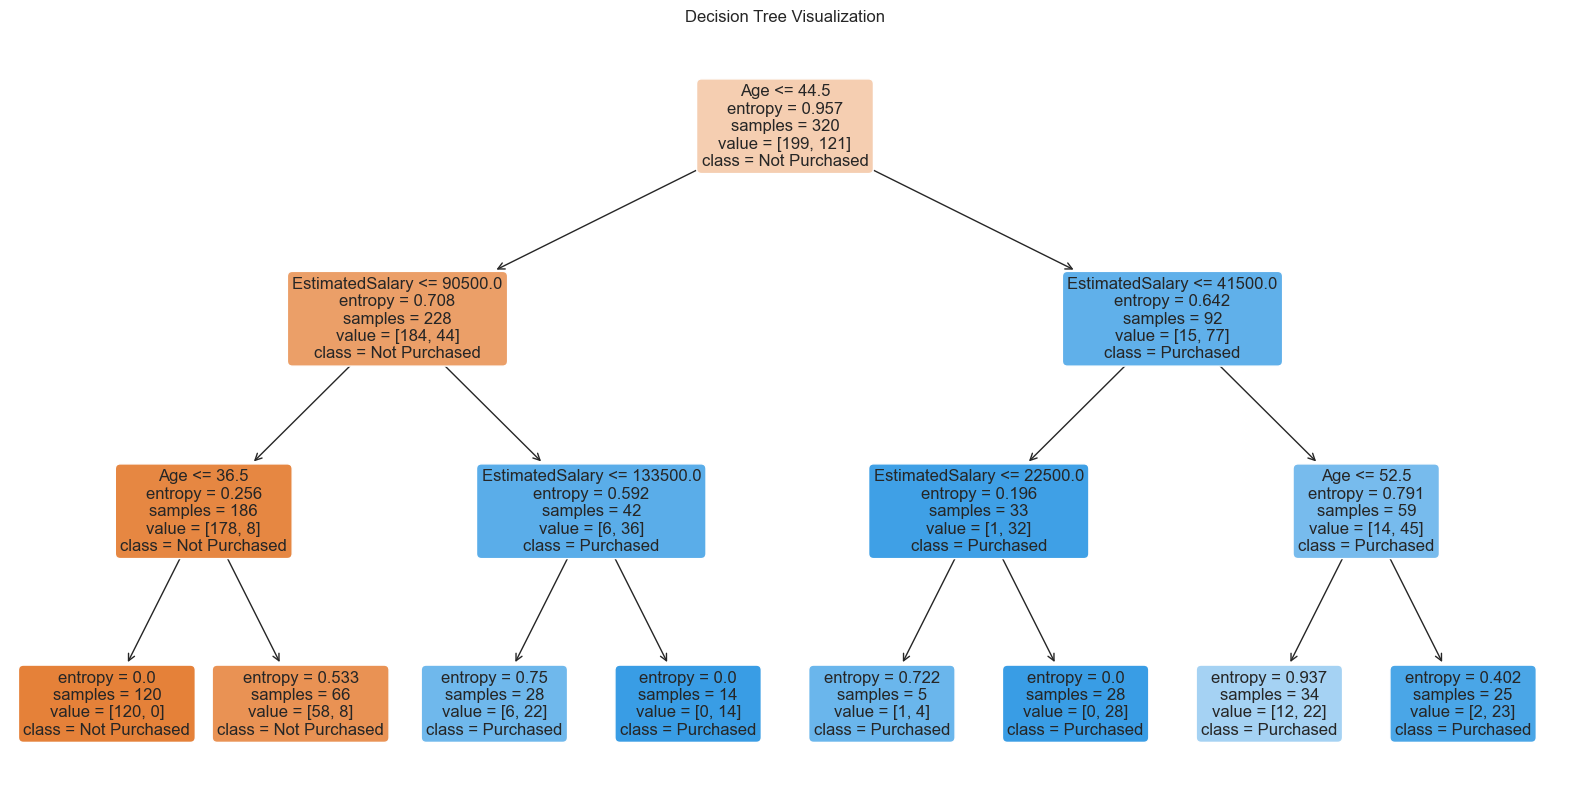

In [33]:
plt.figure(figsize=(20,10))
plot_tree(
    classifier,
    feature_names=['Age', 'EstimatedSalary'],
    class_names=['Not Purchased', 'Purchased'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree Visualization")
plt.show()

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


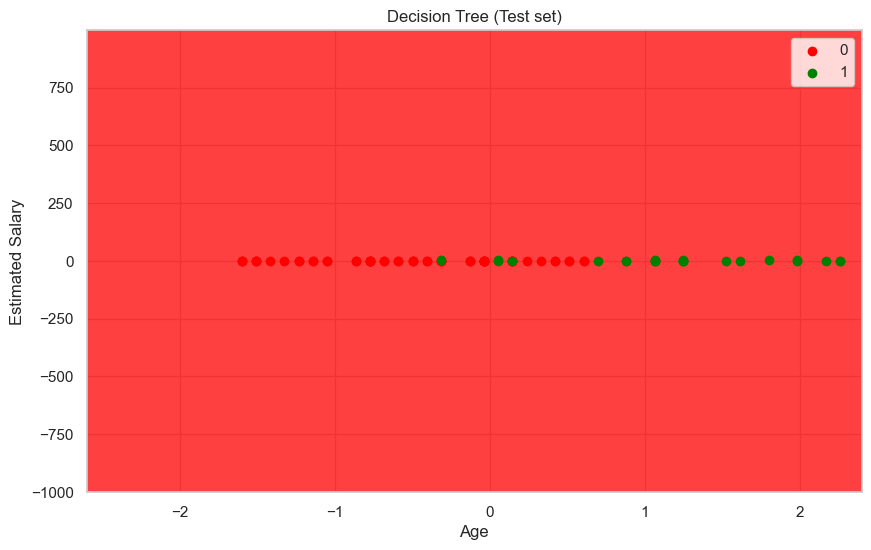

In [34]:
from matplotlib.colors import ListedColormap

x_set, y_set = x_test, y_test
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=1),
    np.arange(start=x_set[:, 1].min() - 1000, stop=x_set[:, 1].max() + 1000, step=1000)
)
plt.figure(figsize=(10,6))
plt.contourf(
    x1, x2, classifier.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
    alpha=0.75, cmap=ListedColormap(('red', 'green'))
)
plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())

for i, j in enumerate(np.unique(y_set)):

    plt.scatter(
        x_set[y_set == j, 0], x_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i), label=j
    )
plt.title('Decision Tree (Test set)')
plt.xlabel('Age')   
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

In [35]:

def predict_purchase():
    try:
        print("--- predict purchase for a new user ---")
        age = int(input("enter age:- "))
        salary = int(input("enter estimated salary:- "))

        new_input = sc.transform([[age,salary]])

        prediction = classifer.predict(new_input)

        if prediction[0] == 1:
            print(f"\nresult: A user aged {age} with a salary of ${salary:,} is likely to purchase")
        else:
            print(f"\nresult: A user aged {age} with a salary of ${salary:,} is NOT likely to purchase")
    except ValueError:
        print("invalid input! pls enter number for age and salary")
predict_purchase()

--- predict purchase for a new user ---

result: A user aged 20 with a salary of $50,000 is NOT likely to purchase
